In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
fileName = "LA_AQS_2023.csv"

df = pd.read_csv(fileName)
df["Date (Local)"] = pd.to_datetime(df["Date (Local)"])

In [89]:
df_NO2 = df[(df['Parameter Name']=='Nitrogen dioxide (NO2)') & (df['Duration Description']=='1 HOUR')].copy()

df_O3 = df[(df['Parameter Name']=='Ozone') & (df['Duration Description']=='1 HOUR')].copy()
df_O3["O3"] = df_O3["Arithmetic Mean"]*1000

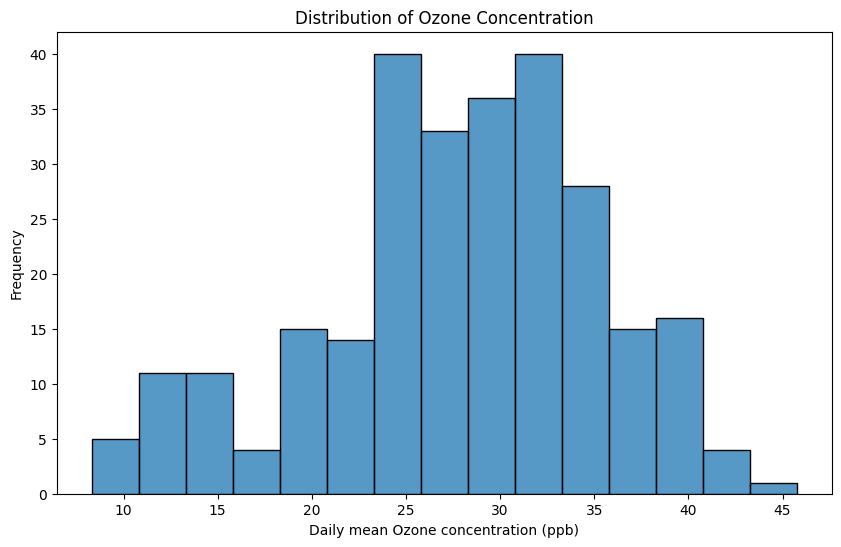

In [90]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_O3, x="O3", bins=15)
plt.title("Distribution of Ozone Concentration")
plt.xlabel("Daily mean Ozone concentration (ppb)")
plt.ylabel("Frequency")
plt.show()

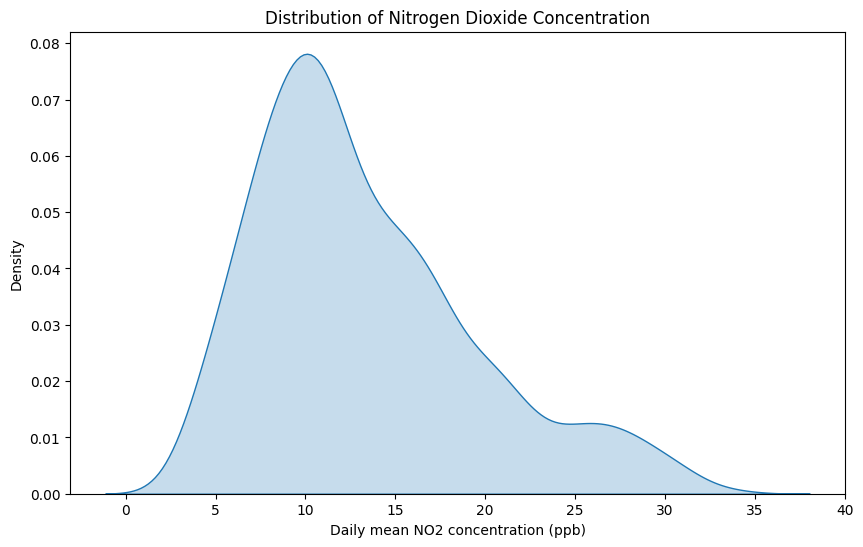

In [91]:
df_NO2["NO2"] = df_NO2["Arithmetic Mean"]

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_NO2, x="NO2", fill=True)
plt.title("Distribution of Nitrogen Dioxide Concentration")
plt.xlabel("Daily mean NO2 concentration (ppb)")
plt.ylabel("Density")
plt.show()

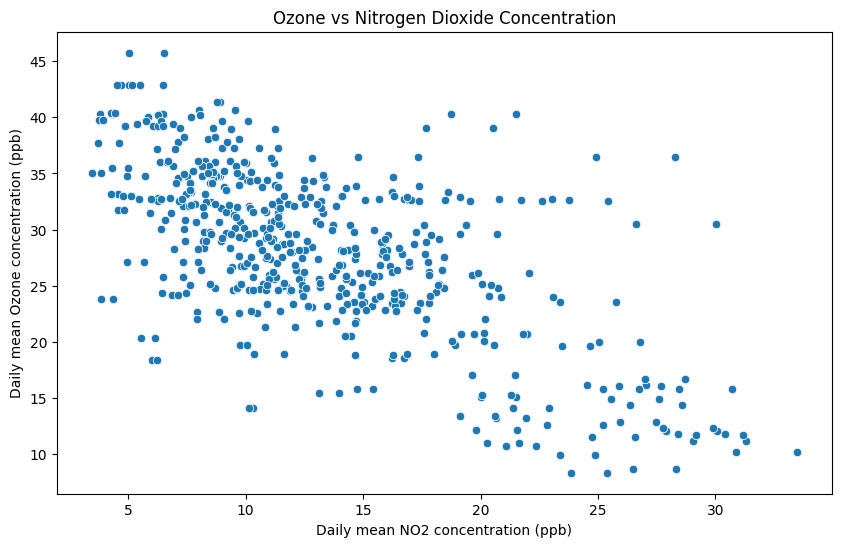

In [92]:
df_all = df_O3[["Date (Local)", "O3"]].merge(df_NO2[["Date (Local)", "NO2"]], on="Date (Local)").dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_all, x="NO2", y="O3")
plt.title("Ozone vs Nitrogen Dioxide Concentration")
plt.xlabel("Daily mean NO2 concentration (ppb)")
plt.ylabel("Daily mean Ozone concentration (ppb)")
plt.show()

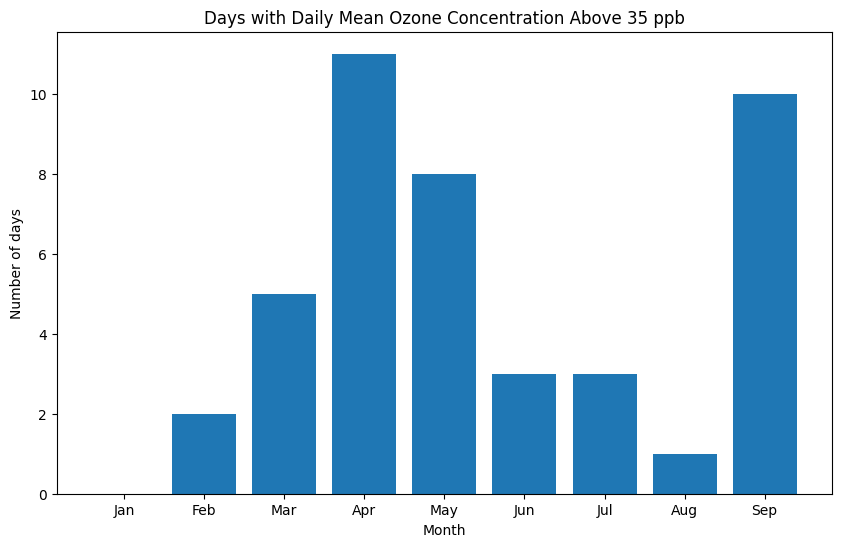

In [93]:
df_O3["Date (Local)"] = pd.to_datetime(df_O3["Date (Local)"])
df_O3["Month"] = df_O3["Date (Local)"].dt.month
df_O3["Above 35"] = df_O3["O3"]>35
monthly_counts = df_O3.groupby("Month")["Above 35"].sum()

plt.figure(figsize=(10, 6))
plt.bar(monthly_counts.index, monthly_counts.values)
plt.title("Days with Daily Mean Ozone Concentration Above 35 ppb")
plt.xlabel("Month")
plt.ylabel("Number of days")
plt.xticks(range(1, 10), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"])
plt.show()

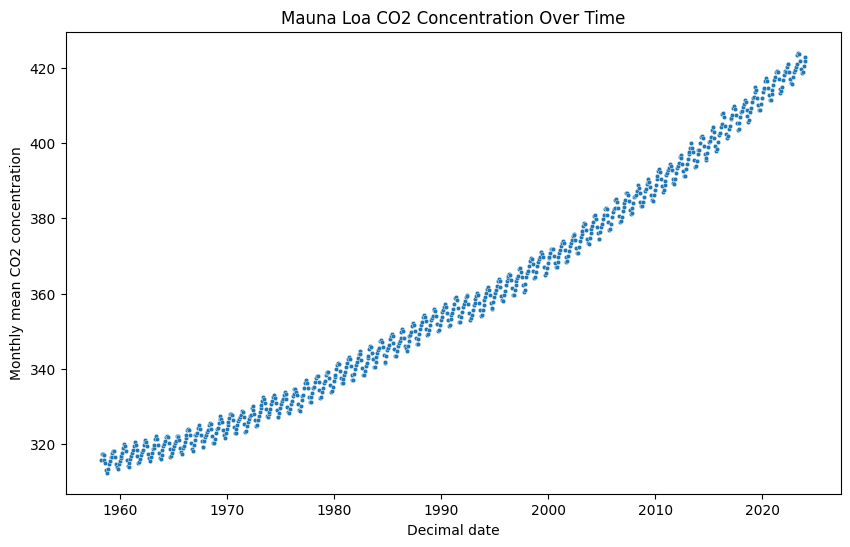

In [94]:
df_CO2 = pd.read_csv("ManuaLoa_CO2.csv")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_CO2, x="decimal date", y="average", s=10)
plt.title("Mauna Loa CO2 Concentration Over Time")
plt.xlabel("Decimal date")
plt.ylabel("Monthly mean CO2 concentration")
plt.show()

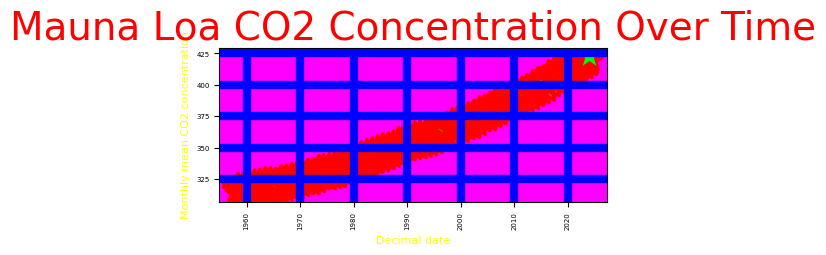

In [95]:
plt.figure(figsize=(5, 2))
sns.scatterplot(data=df_CO2, x="decimal date", y="average", s=500, color="lime", marker="*", edgecolor="red")
plt.gca().set_facecolor("magenta")
plt.title("Mauna Loa CO2 Concentration Over Time", fontsize=28, color="red")
plt.xlabel("Decimal date", fontsize=8, color="yellow")
plt.ylabel("Monthly mean CO2 concentration", fontsize=8, color="yellow")
plt.xticks(rotation=90, fontsize=5)
plt.yticks(fontsize=5)
plt.grid(color="blue", linewidth=6)
plt.show()